# 06 - Large Scale Policy Analysis

Large-scale strategic evaluation of the Mahjong transformer policy.

Goals:
- analyze policy behavior statistically
- evaluate strategic quality
- compare expert vs model decisions
- inspect shanten and ukeire preservation
- identify strengths and failure modes

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import torch
import sqlite3
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

In [3]:
from src.data.tokenizer import MahjongTokenizer

from src.features.tensorization import (
    Tensorizer
)

from src.data.collator import (
    MahjongCollator
)

from src.models.transformer_model import (
    MahjongTransformer
)

from src.analysis.shanten import (
    calculate_shanten
)

from src.analysis.ukeire import (
    evaluate_discards_ukeire
)

from src.utils.action_decoder import (
    decode_action
)

from src.utils.tile_decoder import (
    tile136_to_string
)

from src.analysis.error_analysis import (
    categorize_mistake
)

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [5]:
model = MahjongTransformer(
    embedding_dim=128,
    num_heads=8,
    num_layers=4,
    ff_dim=512,
).to(device)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [6]:
checkpoint = torch.load(
    "../checkpoints/baseline_transformer/epoch_15.pt",

    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

MahjongTransformer(
  (embedding_layer): MahjongEmbedding(
    (token_type_embedding): Embedding(7, 128)
    (tile_embedding): Embedding(35, 128)
    (copy_embedding): Embedding(5, 128)
    (player_embedding): Embedding(5, 128)
    (action_type_embedding): Embedding(13, 128)
    (position_embedding): Embedding(512, 128)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1

In [7]:
tokenizer = MahjongTokenizer()

tensorizer = Tensorizer()

collator = MahjongCollator()

In [8]:
conn = sqlite3.connect(
    "../data/raw/datasets_positive.db"
)

In [9]:
results = []

In [10]:
NUM_SAMPLES = 1000

In [11]:
for offset in tqdm(range(NUM_SAMPLES)):

    # ==================================================
    # LOAD SAMPLE
    # ==================================================

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(query).fetchone()

    decoded = json.loads(
        gzip.decompress(row[0])
    )

    # ==================================================
    # CANONICAL STATE
    # ==================================================

    canonical_state = {

        "round_wind":
            decoded["round_wind"],

        "num_honba":
            decoded["num_honba"],

        "num_riichi":
            decoded["num_riichi"],

        "player_wind":
            decoded["player_wind"],

        "position":
            decoded["position"],

        "remain_tiles":
            decoded["remain_tiles"],

        "dora_indicators":
            decoded["dora_indicators"],

        "hand_tiles":
            decoded["hand_tiles"],

        "players": {

            "0": decoded["0"],
            "1": decoded["1"],
            "2": decoded["2"],
            "3": decoded["3"],
        },

        "valid_actions":
            decoded["valid_actions"],

        "action_idx":
            decoded["action_idx"],
    }

    # ==================================================
    # TOKENIZATION
    # ==================================================

    tokens = tokenizer.tokenize(
        canonical_state
    )

    tensor_dict = tensorizer.tensorize(
        tokens
    )

    batch = collator.collate(
        [tensor_dict]
    )

    # ==================================================
    # MOVE BATCH TO DEVICE
    # ==================================================

    moved = {}

    for key, value in batch.items():

        # ----------------------------------------------
        # list[tensor]
        # ----------------------------------------------

        if isinstance(value, list):

            moved[key] = [
                v.to(device)
                for v in value
            ]

        # ----------------------------------------------
        # normal tensor
        # ----------------------------------------------

        elif torch.is_tensor(value):

            moved[key] = value.to(device)

        # ----------------------------------------------
        # fallback
        # ----------------------------------------------

        else:

            moved[key] = value

    batch = moved

    # ==================================================
    # MODEL INFERENCE
    # ==================================================

    with torch.no_grad():

        logits_list = model(batch)

    logits = logits_list[0]

    probabilities = torch.softmax(
        logits,
        dim=0,
    )

    prediction = torch.argmax(
        probabilities
    ).item()

    # ==================================================
    # ACTIONS
    # ==================================================

    expert_action = canonical_state[
        "valid_actions"
    ][
        canonical_state["action_idx"]
    ]

    model_action = canonical_state[
        "valid_actions"
    ][prediction]

    # ==================================================
    # ONLY ANALYZE DISCARDS
    # ==================================================

    if expert_action["type"] != 1:
        continue

    if model_action["type"] != 1:
        continue

    # ==================================================
    # EXTRACT TILES
    # ==================================================

    expert_tile = expert_action[
        "tiles"
    ][0]

    model_tile = model_action[
        "tiles"
    ][0]

    # ==================================================
    # SHANTEN + UKEIRE ANALYSIS
    # ==================================================

    discard_eval = evaluate_discards_ukeire(
        canonical_state["hand_tiles"]
    )

    discard_lookup = {}

    for r in discard_eval:

        discard_lookup[
            r["discard"]
        ] = r

    expert_metrics = discard_lookup[
        expert_tile
    ]

    model_metrics = discard_lookup[
        model_tile
    ]

    # ==================================================
    # STORE RESULTS
    # ==================================================

    results.append({

        "expert_tile":
            tile136_to_string(
                expert_tile
            ),

        "model_tile":
            tile136_to_string(
                model_tile
            ),

        "same_action":
            expert_tile == model_tile,

        "expert_shanten":
            expert_metrics["shanten"],

        "model_shanten":
            model_metrics["shanten"],

        "expert_ukeire":
            expert_metrics["ukeire"],

        "model_ukeire":
            model_metrics["ukeire"],

        "model_prob":
            probabilities[
                prediction
            ].item(),
    })

    # ==================================================
    # SANITY CHECK FIRST FEW SAMPLES
    # ==================================================

    if offset < 3:

        print()

        print(results[-1])

  0%|          | 0/1000 [00:00<?, ?it/s]/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474893324/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
  0%|          | 5/1000 [00:00<01:31, 10.89it/s]


{'expert_tile': 'east', 'model_tile': 'west', 'same_action': False, 'expert_shanten': 4, 'model_shanten': 4, 'expert_ukeire': 19, 'model_ukeire': 19, 'model_prob': 0.5710635781288147}

{'expert_tile': 'red', 'model_tile': 'west', 'same_action': False, 'expert_shanten': 4, 'model_shanten': 4, 'expert_ukeire': 21, 'model_ukeire': 21, 'model_prob': 0.46417737007141113}

{'expert_tile': 'west', 'model_tile': 'south', 'same_action': False, 'expert_shanten': 3, 'model_shanten': 3, 'expert_ukeire': 10, 'model_ukeire': 10, 'model_prob': 0.5018599629402161}


100%|██████████| 1000/1000 [00:13<00:00, 75.80it/s]


In [12]:
df = pd.DataFrame(results)

In [13]:
df["same_action"].mean()

np.float64(0.696)

In [14]:
(
    df["expert_shanten"]
    ==
    df["model_shanten"]
).mean()

np.float64(0.936)

In [15]:
(
    df["expert_ukeire"]
    -
    df["model_ukeire"]
).abs().mean()

np.float64(0.819)

Text(0.5, 1.0, 'Model Confidence Distribution')

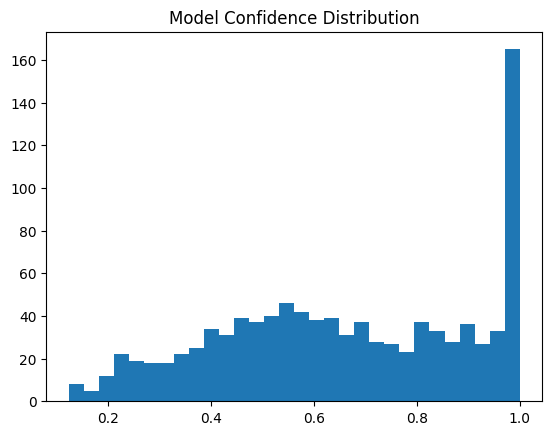

In [16]:
plt.hist(
    df["model_prob"],
    bins=30,
)

plt.title(
    "Model Confidence Distribution"
)

In [17]:
df[
    df["model_shanten"]
    >
    df["expert_shanten"]
].head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,model_prob
32,4s,9s,False,2,3,6,22,0.336476
44,5s,5p,False,0,1,1,11,0.571944
54,8m,1m,False,0,1,2,10,0.272584
107,4s,5p,False,1,2,4,17,0.225248
119,1m,5m,False,0,1,1,10,0.214958
138,7m,8p,False,2,3,6,22,0.345639
165,6p,5p,False,1,2,5,7,0.197840
166,5s,6p,False,0,1,2,6,0.278751
169,4p,8p,False,1,2,5,16,0.252035
171,6m,3p,False,1,2,6,12,0.194470


In [18]:
df[
    (
        df["same_action"] == False
    )
    &
    (
        df["expert_shanten"]
        ==
        df["model_shanten"]
    )
].head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,model_prob
0,east,west,False,4,4,19,19,0.571064
1,red,west,False,4,4,21,21,0.464177
2,west,south,False,3,3,10,10,0.501860
4,2m,7s,False,3,3,18,18,0.372295
8,south,north,False,4,4,25,25,0.494358
9,red,9s,False,4,4,23,21,0.496310
13,1p,7m,False,3,3,16,16,0.268317
15,7m,5s,False,3,3,16,16,0.467587
26,1p,west,False,1,1,4,4,0.873771
27,2s,9p,False,1,1,3,4,0.259785


In [19]:
df["category"] = df.apply(
    categorize_mistake,
    axis=1,
)

In [20]:
df["category"].value_counts(normalize=True)

category
exact_match        0.696
equivalent         0.137
near_equivalent    0.078
shanten_loss       0.040
catastrophic       0.038
ukeire_loss        0.011
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Strategic Mistake Categories')

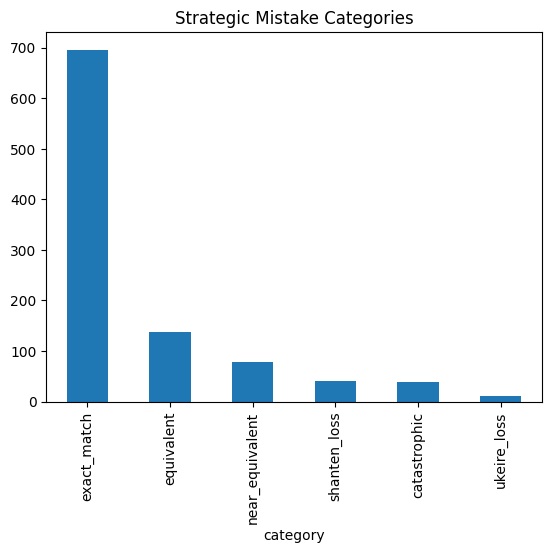

In [21]:
(
    df["category"]
    .value_counts()
    .plot.bar()
)

plt.title(
    "Strategic Mistake Categories"
)